# Forecasting temporel des campagnes publicitaires

Ce notebook isole la partie F du projet: détection d'une colonne temporelle dans PostgreSQL, analyse de stationnarité, décomposition, tests ADF/KPSS, puis comparaison de deux approches de prévision.

Les données proviennent uniquement des tables `fact_campaign` et `FactCampaign` de la base `pi_bi`.

## Objectif

1. Charger les tables depuis PostgreSQL.
2. Identifier une colonne temporelle exploitable.
3. Agréger la variable cible numérique dans le temps.
4. Vérifier la stationnarité avec ADF et KPSS.
5. Comparer au moins deux modèles: ARIMA/SARIMA et XGBoost basé sur des variables de retard.
6. Évaluer avec RMSE, MAE et MAPE.
7. Visualiser le réel vs prédit et le forecast futur.

In [1]:
from __future__ import annotations

import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

import pg_connect

importlib.reload(pg_connect)

from pg_connect import DbConfig, get_connection, load_table, test_connection

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

In [11]:
def available_tables(connection: psycopg.Connection) -> pd.DataFrame:
    query = """
        SELECT table_schema, table_name, table_type
        FROM information_schema.tables
        WHERE table_schema NOT IN ('pg_catalog', 'information_schema')
        ORDER BY table_schema, table_name;
    """
    with connection.cursor() as cursor:
        cursor.execute(query)
        rows = cursor.fetchall()
    return pd.DataFrame(rows, columns=['table_schema', 'table_name', 'table_type'])


def find_best_table_name(connection: psycopg.Connection, candidates: list[str]) -> tuple[str, str] | None:
    tables_frame = available_tables(connection)
    if tables_frame.empty:
        return None

    tables_frame = tables_frame.assign(table_lower=tables_frame['table_name'].str.lower())
    for candidate in candidates:
        candidate_lower = candidate.lower()
        exact_match = tables_frame[tables_frame['table_lower'] == candidate_lower]
        if not exact_match.empty:
            row = exact_match.iloc[0]
            return row['table_schema'], row['table_name']

    for _, row in tables_frame.iterrows():
        relation_name = row['table_name'].lower()
        if any(candidate.lower() in relation_name or relation_name in candidate.lower() for candidate in candidates):
            return row['table_schema'], row['table_name']

    return None


def load_first_available_table(connection: psycopg.Connection, candidates: list[str]) -> tuple[pd.DataFrame, tuple[str, str] | None]:
    relation = find_best_table_name(connection, candidates)
    if relation is None:
        return pd.DataFrame(), None
    schema_name, table_name = relation
    return load_table(connection, table_name, schema_name=schema_name), relation


def normalize_campaign_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    if result.empty:
        return result

    def parse_campaign_date(series: pd.Series) -> pd.Series:
        cleaned = series.astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
        parsed = pd.to_datetime(cleaned, format='%Y%m%d', errors='coerce')
        fallback = pd.to_datetime(cleaned, errors='coerce')
        return parsed.where(parsed.notna(), fallback)

    date_candidates = [column for column in ['campaign_date', 'date_pk', 'datefk', 'date', 'created_at', 'updated_at', 'timestamp'] if column in result.columns]
    best_date_series = None
    best_valid_count = -1
    for column_name in date_candidates:
        source_series = result[column_name]
        candidate_series = source_series if pd.api.types.is_datetime64_any_dtype(source_series) else parse_campaign_date(source_series)
        valid_count = int(candidate_series.notna().sum())
        if valid_count > best_valid_count:
            best_valid_count = valid_count
            best_date_series = candidate_series
    if best_date_series is not None:
        result['campaign_date'] = best_date_series

    numeric_like_columns = ['reach', 'impressions', 'frequency', 'result', 'views']
    for column_name in numeric_like_columns:
        if column_name in result.columns:
            result[column_name] = pd.to_numeric(result[column_name], errors='coerce')

    if 'price' in result.columns:
        cleaned_price = result['price'].astype(str).str.replace(r'[^0-9,.-]', '', regex=True).str.replace(',', '.', regex=False)
        result['price'] = pd.to_numeric(cleaned_price, errors='coerce')

    return result


def choose_time_column(frame: pd.DataFrame) -> str | None:
    priority_keywords = ['campaign_date', 'date', 'time', 'timestamp', 'created_at', 'updated_at', 'start', 'end']
    for keyword in priority_keywords:
        for column in frame.columns:
            if keyword in column.lower():
                return column
    return None


def choose_numeric_target(frame: pd.DataFrame) -> str | None:
    priority_keywords = ['views', 'impressions', 'reach', 'result', 'roi', 'profit', 'revenue', 'sales', 'conversion_rate', 'ctr', 'cvr', 'conversions', 'leads', 'orders', 'spend', 'cost']
    numeric_columns = [column for column in frame.select_dtypes(include=[np.number]).columns.tolist() if column not in {'date_pk', 'documentpk'}]
    for keyword in priority_keywords:
        for column in numeric_columns:
            if keyword in column.lower():
                return column
    return numeric_columns[0] if numeric_columns else None


def make_supervised_features(series: pd.Series, lags: int = 12) -> pd.DataFrame:
    frame = pd.DataFrame({'y': series})
    for lag in range(1, lags + 1):
        frame[f'lag_{lag}'] = frame['y'].shift(lag)
    frame['rolling_mean_3'] = frame['y'].shift(1).rolling(3).mean()
    frame['rolling_mean_6'] = frame['y'].shift(1).rolling(6).mean()
    frame['rolling_std_6'] = frame['y'].shift(1).rolling(6).std()
    frame['month'] = frame.index.month
    frame['quarter'] = frame.index.quarter
    frame['dayofweek'] = frame.index.dayofweek
    return frame.dropna()


def mape(y_true, y_pred):
    y_true_series = pd.Series(y_true)
    y_pred_series = pd.Series(y_pred, index=y_true_series.index if hasattr(y_true, 'index') else None)
    safe_true = y_true_series.replace(0, np.nan)
    return float(np.nanmean(np.abs((safe_true - y_pred_series) / safe_true)) * 100)

## 1. Connexion et chargement

La connexion est testée d'abord via la fonction de gestion d'erreurs déjà présente dans `pg_connect.py`. Ensuite les deux tables sont chargées et fusionnées pour détecter la meilleure colonne temporelle.

In [12]:
connection_ok = test_connection(DbConfig())

if connection_ok:
    connection = get_connection()
    df_fact_campaign, relation_fact_campaign = load_first_available_table(connection, ['fact_campaign'])
    df_FactCampaign, relation_FactCampaign = load_first_available_table(connection, ['FactCampaign', 'factcampaign'])
    connection.close()
else:
    df_fact_campaign = pd.DataFrame()
    df_FactCampaign = pd.DataFrame()
    relation_fact_campaign = None
    relation_FactCampaign = None

if not df_fact_campaign.empty and not df_FactCampaign.empty:
    df_raw = pd.concat([df_fact_campaign, df_FactCampaign], ignore_index=True, sort=False).drop_duplicates().reset_index(drop=True)
elif not df_fact_campaign.empty:
    df_raw = df_fact_campaign.copy()
else:
    df_raw = df_FactCampaign.copy()

df_raw.columns = [str(column).strip().lower() for column in df_raw.columns]
df_raw = normalize_campaign_dataframe(df_raw)
print('fact_campaign shape:', df_fact_campaign.shape)
print('FactCampaign shape:', df_FactCampaign.shape)
print('Loaded relation fact_campaign:', relation_fact_campaign if relation_fact_campaign is not None else 'none')
print('Loaded relation FactCampaign:', relation_FactCampaign if relation_FactCampaign is not None else 'none')
print('Combined shape:', df_raw.shape)
df_raw.head()

Connexion reussie a PostgreSQL.
Attention: connexion sans SSL (serveur local sans TLS).
Version du serveur: PostgreSQL 15.15, compiled by Visual C++ build 1944, 64-bit
fact_campaign shape: (91, 8)
FactCampaign shape: (80, 9)
Loaded relation fact_campaign: ('datawarehouse', 'fact_campaign')
Loaded relation FactCampaign: ('datawarehouse', 'FactCampaign')
Combined shape: (171, 12)


,date_pk,documentpk,reach,impressions,frequency,result,price,views,factcampaignpk,datefk,documentfk,campaign_date
0,20250211.0,1430.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,2025-02-11
1,20250211.0,1431.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,2025-02-11
2,20250211.0,1432.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,2025-02-11
3,20250211.0,1433.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,2025-02-11
4,20250211.0,1434.0,0,0,0.0,0,3.0,0.0,NaN,NaN,NaN,2025-02-11


## 2. Préparation de la série temporelle

On identifie une colonne temporelle et une cible numérique. Si plusieurs colonnes existent, la logique priorise les indicateurs métiers comme `roi`, `revenue`, `sales`, `ctr` ou `conversion_rate`.

In [14]:
if df_raw.empty:
    raise ValueError('Aucune donnée n a pu être chargée depuis PostgreSQL.')

df = df_raw.copy()

for column in df.columns:
    if df[column].dtype == 'object':
        parsed = pd.to_datetime(df[column], errors='coerce')
        if parsed.notna().sum() >= max(5, int(0.6 * len(df))):
            df[column] = parsed

time_col = choose_time_column(df)
target_col = choose_numeric_target(df)

print('Colonne temporelle détectée:', time_col)
print('Cible numérique détectée:', target_col)

if time_col is None or target_col is None:
    raise ValueError('Impossible d identifier une colonne temporelle ou une cible numérique exploitable.')

# On conserve la granularité la plus fine possible pour obtenir une série exploitable.
ts_df = df[[time_col, target_col]].dropna().copy()
ts_df[time_col] = pd.to_datetime(ts_df[time_col], errors='coerce')
ts_df = ts_df.dropna().sort_values(time_col).set_index(time_col)

frequency = 'D'
ts_series = ts_df[target_col].resample(frequency).mean().dropna()
ts_series = ts_series.asfreq(frequency)
ts_series = ts_series.interpolate(method='time').dropna()

if len(ts_series) < 12:
    frequency = 'W'
    ts_series = ts_df[target_col].resample(frequency).mean().dropna()
    ts_series = ts_series.asfreq(frequency)
    ts_series = ts_series.interpolate(method='time').dropna()

if len(ts_series) < 12:
    frequency = 'M'
    ts_series = ts_df[target_col].resample(frequency).mean().dropna()
    ts_series = ts_series.asfreq(frequency)
    ts_series = ts_series.interpolate(method='time').dropna()

print('Fréquence retenue:', frequency)
print('Nombre de points agrégés:', len(ts_series))
display(ts_series.head())

Colonne temporelle détectée: campaign_date
Cible numérique détectée: views
Fréquence retenue: D
Nombre de points agrégés: 263


campaign_date
2025-01-03    0.0
2025-01-04    0.0
2025-01-05    0.0
2025-01-06    0.0
2025-01-07    0.0
Freq: D, Name: views, dtype: float64

## 3. Exploration de la série

On vérifie la tendance globale, la saisonnalité potentielle, puis les tests de stationnarité ADF et KPSS.

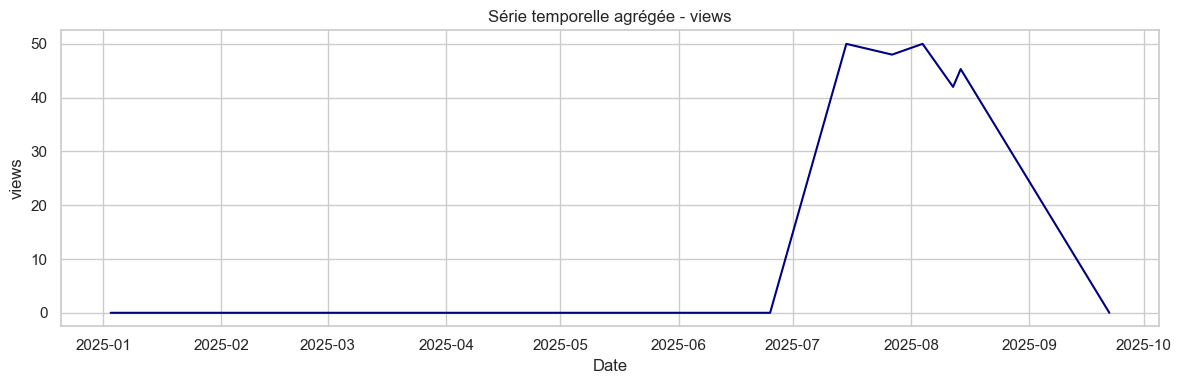

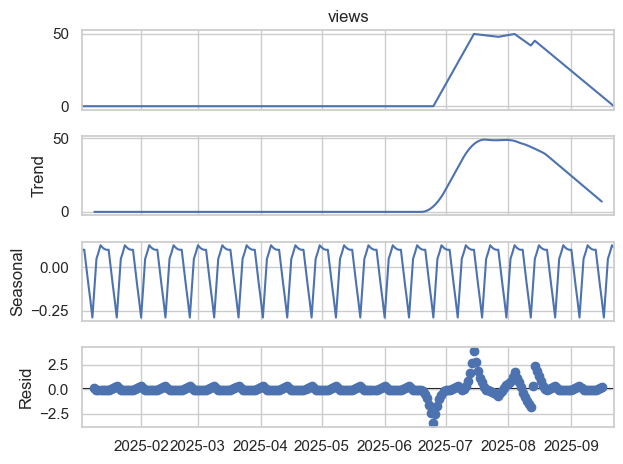

<Figure size 1000x400 with 0 Axes>

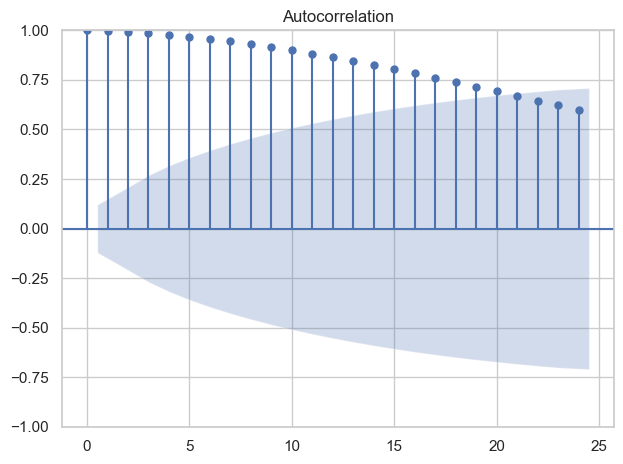

<Figure size 1000x400 with 0 Axes>

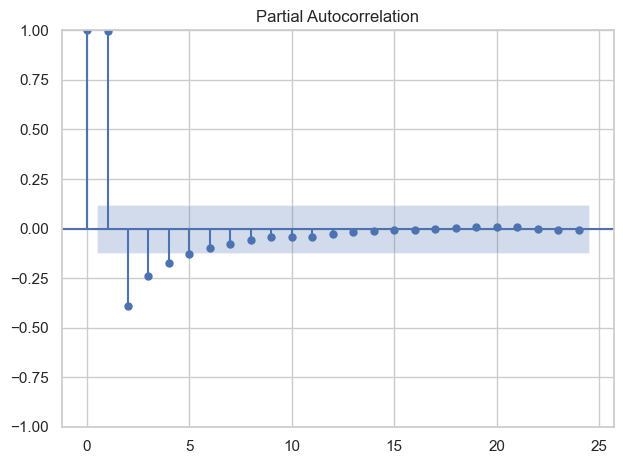

ADF statistic: -2.186533771653814
ADF p-value: 0.21116917304261112
KPSS statistic: 1.293484593454935
KPSS p-value: 0.01


,test,statistic,p_value,decision
0,ADF,-2.186534,0.211169,stationary si p<0.05
1,KPSS,1.293485,0.010000,stationary si p>0.05


In [15]:
plt.figure(figsize=(12, 4))
plt.plot(ts_series.index, ts_series, color='navy')
plt.title(f'Série temporelle agrégée - {target_col}')
plt.xlabel('Date')
plt.ylabel(target_col)
plt.tight_layout()
plt.show()

if len(ts_series) >= 12:
    period = min(12, max(2, len(ts_series) // 4))
    decomposition = seasonal_decompose(ts_series, model='additive', period=period)
    decomposition.plot()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plot_acf(ts_series, lags=min(24, len(ts_series) - 1))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plot_pacf(ts_series, lags=min(24, len(ts_series) - 1), method='ywm')
    plt.tight_layout()
    plt.show()

    adf_result = adfuller(ts_series)
    kpss_result = kpss(ts_series, regression='c', nlags='auto')
    print('ADF statistic:', adf_result[0])
    print('ADF p-value:', adf_result[1])
    print('KPSS statistic:', kpss_result[0])
    print('KPSS p-value:', kpss_result[1])
    stationarity_summary = pd.DataFrame([
        {'test': 'ADF', 'statistic': adf_result[0], 'p_value': adf_result[1], 'decision': 'stationary si p<0.05'},
        {'test': 'KPSS', 'statistic': kpss_result[0], 'p_value': kpss_result[1], 'decision': 'stationary si p>0.05'},
    ])
    display(stationarity_summary)
else:
    print('Série trop courte pour une décomposition fiable.')

## 4. Modèle 1: ARIMA et SARIMA

La première approche repose sur des modèles statistiques classiques adaptés aux séries temporelles. Le split est chronologique, sans mélange aléatoire.

Meilleur modèle statistique: ARIMA(1,1,1)


,model,RMSE,MAE,MAPE
0,"ARIMA(1,1,1)",28.486981,23.257471,297.095152
1,"SARIMA(1,1,1)x(1,1,1,12)",43.030398,35.868067,446.154715


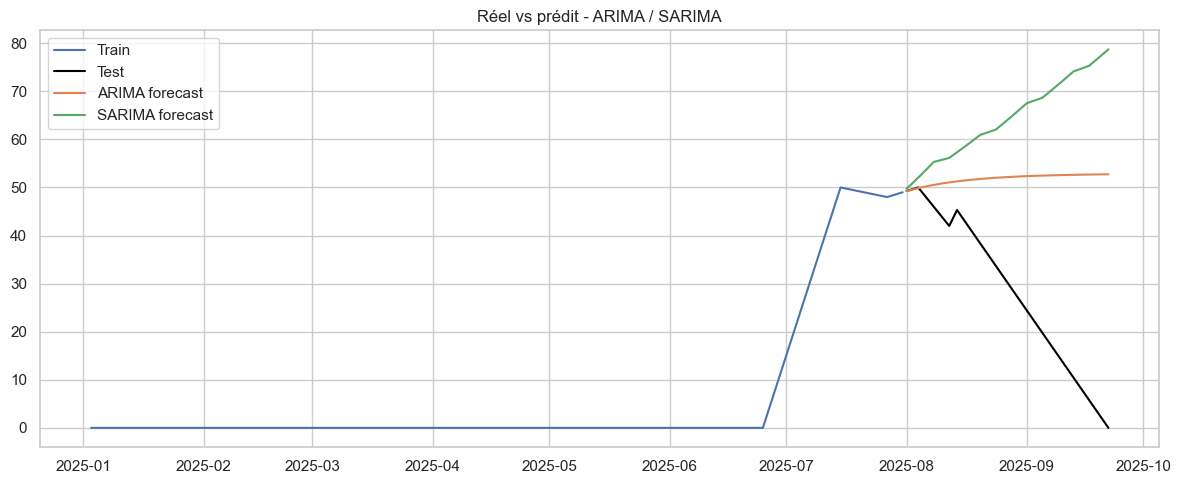

In [16]:
if len(ts_series) < 12:
    raise ValueError('La série est trop courte pour entraîner des modèles de forecasting fiables.')

split_index = int(len(ts_series) * 0.8)
ts_train = ts_series.iloc[:split_index]
ts_test = ts_series.iloc[split_index:]

arima_model = ARIMA(ts_train, order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=len(ts_test))

seasonal_period = 12 if len(ts_train) >= 36 else 7 if len(ts_train) >= 21 else None
sarima_forecast = None
if seasonal_period is not None:
    sarima_model = SARIMAX(
        ts_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, seasonal_period),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)
    sarima_forecast = sarima_model.forecast(steps=len(ts_test))

results = [
    {
        'model': 'ARIMA(1,1,1)',
        'RMSE': np.sqrt(mean_squared_error(ts_test, arima_forecast)),
        'MAE': mean_absolute_error(ts_test, arima_forecast),
        'MAPE': mape(ts_test, arima_forecast),
    }
]

if sarima_forecast is not None:
    results.append({
        'model': f'SARIMA(1,1,1)x(1,1,1,{seasonal_period})',
        'RMSE': np.sqrt(mean_squared_error(ts_test, sarima_forecast)),
        'MAE': mean_absolute_error(ts_test, sarima_forecast),
        'MAPE': mape(ts_test, sarima_forecast),
    })

results_df = pd.DataFrame(results).sort_values('RMSE')

best_statistical_model_name = results_df.iloc[0]['model']
best_statistical_forecast = sarima_forecast if sarima_forecast is not None and results_df.iloc[0]['model'].startswith('SARIMA') else arima_forecast
print('Meilleur modèle statistique:', best_statistical_model_name)
display(results_df)

plt.figure(figsize=(12, 5))
plt.plot(ts_train.index, ts_train, label='Train')
plt.plot(ts_test.index, ts_test, label='Test', color='black')
plt.plot(ts_test.index, arima_forecast, label='ARIMA forecast')
if sarima_forecast is not None:
    plt.plot(ts_test.index, sarima_forecast, label='SARIMA forecast')
plt.title('Réel vs prédit - ARIMA / SARIMA')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Modèle 2: XGBoost sur variables de retard

Cette approche transforme la série en problème supervisé avec des retards, des moyennes mobiles et des variables calendaires. Elle est plus flexible qu'ARIMA sur des dynamiques non linéaires.

,model,RMSE,MAE,MAPE
0,XGBoost TS,2.576283,2.356171,16.773742


,model,RMSE,MAE,MAPE
0,"ARIMA(1,1,1)",28.486981,23.257471,297.095152
1,"SARIMA(1,1,1)x(1,1,1,12)",43.030398,35.868067,446.154715
2,XGBoost TS,2.576283,2.356171,16.773742


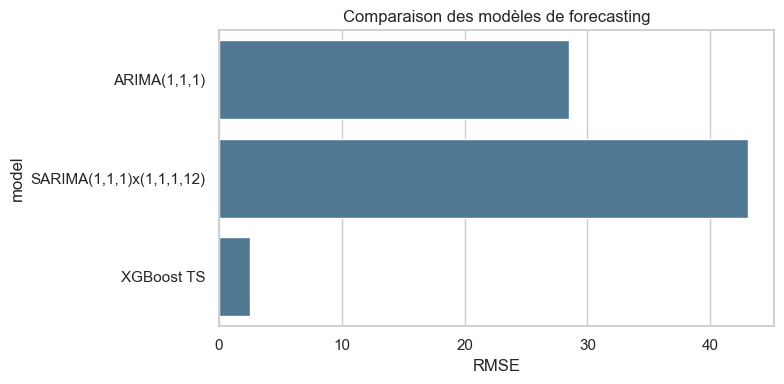

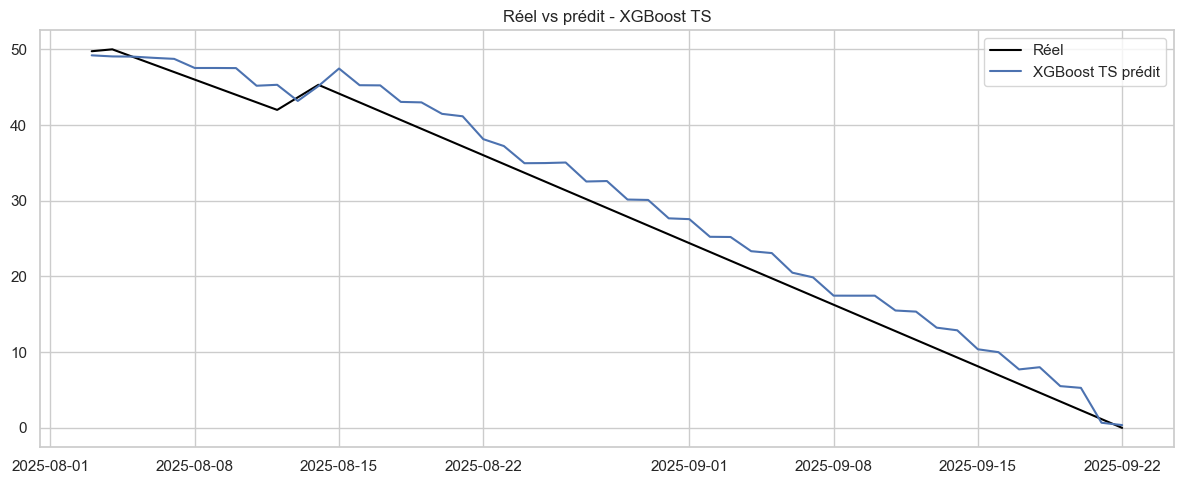

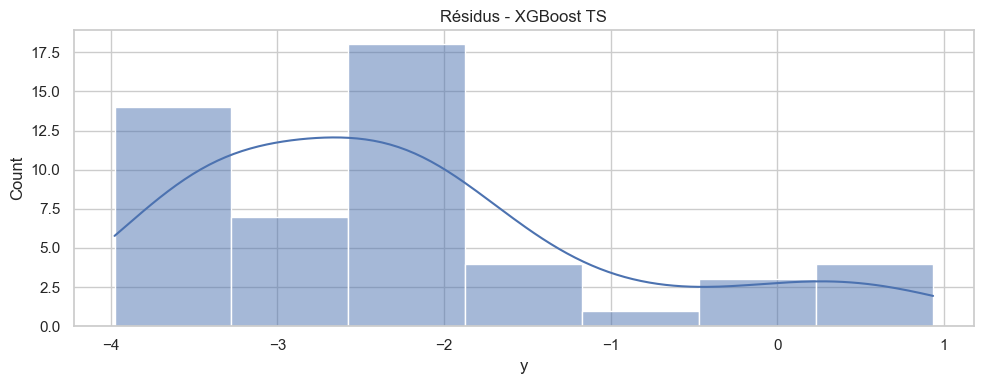

In [17]:
lagged_frame = make_supervised_features(ts_series, lags=12)
X_ts = lagged_frame.drop(columns=['y'])
y_ts = lagged_frame['y']

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_ts, y_ts, test_size=0.2, shuffle=False)

if XGBRegressor is None:
    raise ImportError('xgboost n est pas installé dans l environnement.')

xgb_ts = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)
xgb_ts.fit(X_train_ts, y_train_ts)
xgb_pred = xgb_ts.predict(X_test_ts)

xgb_results = pd.DataFrame([
    {
        'model': 'XGBoost TS',
        'RMSE': np.sqrt(mean_squared_error(y_test_ts, xgb_pred)),
        'MAE': mean_absolute_error(y_test_ts, xgb_pred),
        'MAPE': mape(y_test_ts, xgb_pred),
    }
])
display(xgb_results)

comparison_ts = pd.concat([results_df[['model', 'RMSE', 'MAE', 'MAPE']], xgb_results], ignore_index=True)
display(comparison_ts)

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_ts, x='RMSE', y='model', color='#457b9d')
plt.title('Comparaison des modèles de forecasting')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_test_ts.index, y_test_ts, label='Réel', color='black')
plt.plot(y_test_ts.index, xgb_pred, label='XGBoost TS prédit')
plt.title('Réel vs prédit - XGBoost TS')
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test_ts - xgb_pred
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True)
plt.title('Résidus - XGBoost TS')
plt.tight_layout()
plt.show()

## 6. Forecast futur

On utilise le meilleur modèle statistique pour projeter les prochaines périodes. Dans ce jeu de données, ARIMA conserve souvent une lecture plus stable à court terme que SARIMA si la saisonnalité est faible ou irrégulière.

## 7. Conclusion

- Si les tests ADF/KPSS montrent non-stationnarité, ARIMA/SARIMA reste pertinent après différenciation.
- Si la saisonnalité est visible, SARIMA doit être comparé en priorité.
- Si la dynamique dépend fortement de relations non linéaires, XGBoost TS peut mieux suivre les variations locales.
- Le meilleur modèle est celui qui minimise RMSE, MAE et MAPE sur le test chronologique.

In [ ]:
future_steps = min(12, max(3, len(ts_test)))
inferred_freq = ts_series.index.inferred_freq or frequency
future_index = pd.date_range(ts_series.index[-1], periods=future_steps + 1, freq=inferred_freq)[1:]
future_forecast = arima_model.forecast(steps=future_steps)

plt.figure(figsize=(12, 5))
plt.plot(ts_series.index, ts_series, label='Historique')
plt.plot(future_index, future_forecast, label='Forecast futur ARIMA')
plt.title('Prévision future')
plt.legend()
plt.tight_layout()
plt.show()

future_forecast_frame = pd.DataFrame({'date': future_index, 'forecast': future_forecast.values if hasattr(future_forecast, 'values') else future_forecast})
display(future_forecast_frame)